# Predicción del abandono de clientes en telecomunicaciones

## Descripción del problema y análisis exploratorio de datos Dataset: Telco Customer Churn

## 1. Contexto del problema
En la industria de telecomunicaciones, la pérdida de clientes (customer churn) representa un problema crítico debido a que adquirir nuevos clientes suele ser significativamente más costoso que mantener los existentes. Identificar de manera temprana a los clientes con alta probabilidad de abandono permite diseñar estrategias de retención más efectivas.
Este problema puede abordarse mediante técnicas de aprendizaje automático, modelando la probabilidad de abandono a partir de variables demográficas, servicios contratados y comportamientos de facturación de servicios. Todo esto posibilita la implementación de estrategias preventivas como ofertas personalizadas, mejoras en el servicio o planes de fidelización dirigidos específicamente a clientes en riesgo.

El objetivo de este proyecto es desarrollar un modelo de clasificación supervisada capaz de estimar la probabilidad de abandono a partir de variables estructuradas del dataset **Telco Customer Churn**.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/DahianaRH/customer-churn-prediction-ml/main/data/telco_customer_churn.csv"
df = pd.read_csv(url)

### Exploración General

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


La muestra del dataset evidencia que se cuenta con variables demográficas, de servicios contratados y de facturación, las cuales serán utilizadas para predecir la variable objetivo Churn.

In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


El dataset contiene 7043 registros y 21 variables, predominando las variables categóricas. No se observan valores nulos inicialmente, aunque TotalCharges requiere conversión a tipo numérico para su correcto análisis.

## 2. Descripción del dataset
El dataset contiene información de aproximadamente 7000 clientes y 21 variables, incluyendo datos demográficos, servicios contratados y variables de facturación.

La variable objetivo es **Churn**, que nos indica si el cliente abandonó el servicio (Yes/No).

### Tipos de variables

In [7]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


La mayoría de las variables son categóricas y deberán ser codificadas. Además, TotalCharges requiere conversión a tipo numérico para su correcto análisis.

### Análisis de valores faltantes

In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Se observa que la mayoría de las variables no presentan valores faltantes. Sin embargo, la variable TotalCharges contiene 11 valores nulos, los cuales representan una proporción muy pequeña del dataset. Por esta razón se decide eliminar estas filas para evitar inconsistencias en el análisis.

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).copy()

In [13]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Luego del tratamiento, se verifica que el dataset no presenta valores faltantes en ninguna variable, por lo que se encuentra listo para las etapas posteriores de análisis y modelado.

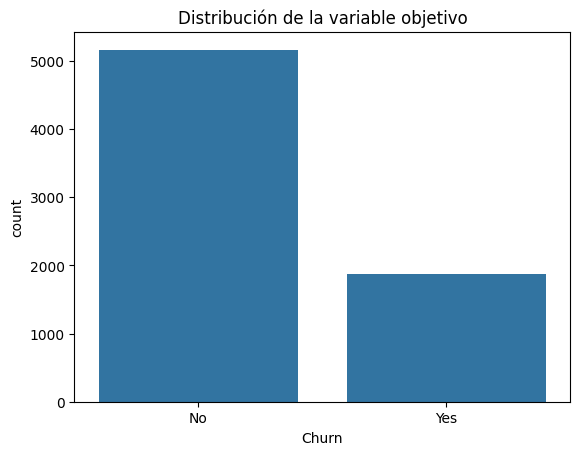

In [14]:
sns.countplot(x='Churn', data=df)
plt.title("Distribución de la variable objetivo")
plt.show()

Se observa un desbalance de clases, lo cual debemos tener en consideración en etapas posteriores mediante técnicas de balanceo o métricas adecuadas, pues métricas cómo accuracy no son suficientes. Se deberán considerar métricas como F1-score, ROC-AUC o PR-AUC.

In [15]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Las variables numéricas muestran una alta variabilidad. tenure indica que existen tanto clientes nuevos como antiguos.
MonthlyCharges presenta distintos niveles de cobro según el tipo de servicio.
TotalCharges varía ampliamente, lo cual es consistente con su relación con el tiempo de permanencia y el costo mensual.
Además, se observan algunos valores faltantes en esta última variable.

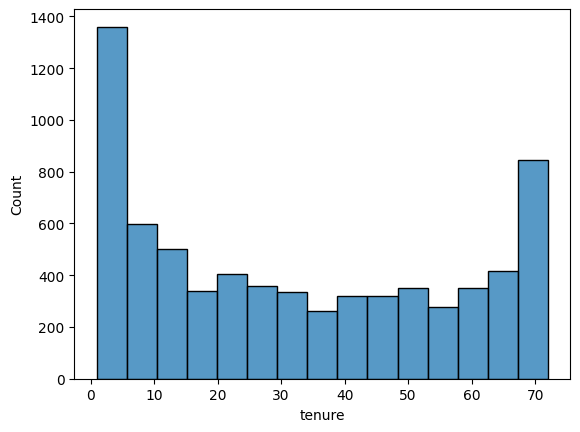

In [16]:
sns.histplot(df['tenure'])
plt.show()

La variable tenure, que representa el tiempo de permanencia del cliente, presenta una distribución no uniforme. Se observa una alta concentración de clientes en los primeros meses, así como un segundo grupo importante de clientes con larga permanencia (mayor a 60 meses). Esto sugiere la existencia de dos perfiles:
1.   Clientes nuevos con mayor probabilidad de abandono
2.   Clientes consolidados con menor riesgo.

Esto nos indica que esta variable tiene un alto poder predictivo para el problema de churn.

In [22]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

La variable objetivo Churn fue codificada en formato binario, asignando el valor 1 a los clientes que abandonan el servicio (Yes) y 0 a los que permanecen (No), con el fin de ser utilizada en modelos de clasificación supervisada.

## 3. Paradigma de aprendizaje

El problema se aborda como una tarea de **clasificación supervisada**, ya que se dispone de etiquetas (Churn) y el objetivo es predecir si un cliente abandonará el servicio.

Sea **X** el conjunto de variables predictoras y **y = Churn** la variable objetivo.
El problema se formula como una clasificación binaria supervisada donde se busca aprender una función **f(X) → y.**

Este enfoque es adecuado debido a la naturaleza del problema y la disponibilidad de datos históricos etiquetados.

In [23]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

## 4. Entrenamiento y Evaluación de los Modelos

### 4.1. Configuración Experimental

### Metodología de validación:
Se realizó el entranamiento y evaluación de diferentes modelos de clasificación supervisada con el objetivo de predecir el abandono de clientes (Churn) en una empresa de telecomunicaciones.

El dataset fue dividido en conjuntos de entrenamiento y prueba utilizando la partición estratificada de:

*   80% para entrenamiento
*   20% para pruebas

La estratificación se realizó utilizando la variable objetivo (abandono) Churn, con el fin de conservar la proporción original de clases tanto en entrenamiento como en prueba y evitar sesgos derivados del desbalance del dataset.

Debido a que el problema presenta una distribución dasbalanceada entre clientes que abandonan y clientes que permanecen en el servicio, el uso exclusivo de la métrica Accuracy no resulta suficiente para evaluar adecuadamente el comportamiento de los modelos. Por esta razón, en aquellos algoritmos compatibles se utilizó el parámetro class_weight='balanced', permitiendo asignar un mayor peso a la clase minoritaria durante el entrenamiento.

En la etapa de preprocesamiento, las variables categóricas fueron transformadas mediante codificación One-Hot Encoding, mientras que las variables numéricas fueron estandarizadas utilizando StandardScaler. Este procedimiento permitió garantizar que las variables continuas tuvieran una escala homogénea y facilitó el correcto funcionamiento de modelos sensibles a la magnitud de los datos, como SVM y redes neuronales.

Adicionalmente, para obtener una estimación más robusta del desempeño de los modelos y reducir la dependencia de una única partición de entranamiento, se utilizó validación cruzada estratificada (StratifiedKFold) con cinco particiones durante el proceso de optimización de hiperparámetros mediante GridSearchCV.

In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import seaborn as sns

### Preparación de variables

In [25]:
# Variables numéricas y categóricas
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

# Preprocesamiento
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Validación cruzada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Modelos e hiperparámetros evaluados

Con el objetivo de comparar diferentes enfoques de aprendizaje automático, se evaluaron cinco modelos de clasificación supervisada pertenecientes a distintos paradigmas de aprendizaje:
*   Regresión logística
*   K-Nearest Neighbors (KNN)
*   Random Forest
*   Máquina de vectores de soporte (SVM)
*   Red neuronal artificial (MLP)

La selección de estos modelos permitió incluir algoritmos lineales, no paramétricos, basados en árboles, redes neuronales y métodos de separación mediante hiperplanos.

La Tabla 1 resume los hiperparámetros analizados para cada modelo durante el proceso de búsqueda exhaustiva utilizando GridSearchCV.

### Tabla 1. Hiperparámetros evaluados

| Modelo | Hiperparámetros |
|---|---|
| Logistic Regression | C = [0.01, 0.1, 1, 10] |
| KNN | n_neighbors = [3, 5, 7, 9] |
| Random Forest | n_estimators = [100, 200], max_depth = [5, 10, None] |
| SVM | C = [0.1, 1, 10], kernel = ['linear', 'rbf'] |
| MLP | hidden_layer_sizes = [(50,), (100,), (50,50)] |

In [26]:
models = {
    "Logistic Regression": (
        LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        ),
        {
            'model__C': [0.01, 0.1, 1, 10]
        }
    ),

    "KNN": (
        KNeighborsClassifier(),
        {
            'model__n_neighbors': [3,5,7,9]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(
            random_state=42,
            class_weight='balanced'
        ),
        {
            'model__n_estimators': [100,200],
            'model__max_depth': [5,10,None]
        }
    ),

    "SVM": (
        SVC(
            probability=True,
            class_weight='balanced'
        ),
        {
            'model__C': [0.1,1,10],
            'model__kernel': ['linear','rbf']
        }
    ),

    "MLP": (
        MLPClassifier(max_iter=1000),
        {
            'model__hidden_layer_sizes': [
                (50,),
                (100,),
                (50,50)
            ]
        }
    )
}

### Métricas de desempeño

Considerando el desbalance presente en la variable objetivo, se utilizaron diferentes métricas de evaluación con el fin de analizar el desempeño de los modelos desde múltiples perspectivas.

Las métricas empleadas fueron:
*   Accuracy
*   Precision
*   Recall
*   F1-score
*   ROC-AUC

La métrica Recall resulta especialmente importante en este problema, ya que mide la capacidad del modelo para identificar correctamente clientes con riesgo de abandono. Desde un punto de vista empresarial, minimizar falsos negativos es fundamental, debido a que representa clientes que abandonarían el servicio sin ser detectados oportunamente.

Por otro lado, el F1-score permite obtener un balance entre Precision y Recall, siendo particularmente útil en problemas con clases desbalanceadas. Finalmente, la métrica ROC-AUC evalúa la capacidad global del modelo para distinguir entre ambas clases independientemente del umbral de clasificación utilizado.

Adicionalmente, para cada modelo se estimaron intervalos de confianza del 95% sobre el F1-score utilizando los resultados obtenidos durante la validación cruzada estratificada. Estos intervalos permiten cuantificar la variabilidad del desempeño y proporcionan una estimación más robusta de la capacidad de generalización de los modelos.

Los intervalos fueron calculados utilizando la distribución t de Student a partir de los resultados obtenidos en las cinco particiones de validación cruzada.

### 4.2. Resultados del entrenamiento de modelos

In [27]:
from scipy.stats import t

results = []

best_models = {}

for name, (model, params) in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid = GridSearchCV(
        pipeline,
        params,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    best_models[name] = best_model

    # =========================
    # VALIDACIÓN CRUZADA
    # =========================

    cv_scores = cross_val_score(
        best_model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1'
    )

    mean_cv = np.mean(cv_scores)
    std_cv = np.std(cv_scores)

    # Intervalo de confianza 95%
    confidence = 0.95
    n = len(cv_scores)

    margin_error = t.ppf(
        (1 + confidence) / 2,
        df=n-1
    ) * (std_cv / np.sqrt(n))

    ci_lower = mean_cv - margin_error
    ci_upper = mean_cv + margin_error

    # =========================
    # TEST
    # =========================

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'CV Mean F1': round(mean_cv, 4),
        '95% CI Lower': round(ci_lower, 4),
        '95% CI Upper': round(ci_upper, 4),
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4)
    })

In [28]:
results_df = pd.DataFrame(results)

results_df[
    [
        'Model',
        'CV Mean F1',
        '95% CI Lower',
        '95% CI Upper',
        'Accuracy',
        'Recall',
        'F1-score',
        'ROC-AUC'
    ]
]

,Model,CV Mean F1,95% CI Lower,95% CI Upper,Accuracy,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.6322,0.6236,0.6408,0.7257,0.7968,0.6069,0.8351
1,KNN,0.5740,0.5440,0.6040,0.7711,0.5588,0.5649,0.8039
2,Random Forest,0.6301,0.6204,0.6398,0.7242,0.7834,0.6016,0.8331
3,SVM,0.6263,0.6151,0.6376,0.7292,0.7727,0.6027,0.8056
4,MLP,0.5403,0.5155,0.5650,0.7562,0.5080,0.5256,0.7863


### Tabla 2. Resultados de desempeño de los modelos

La Tabla 2 presenta los resultados obtenidos por los diferentes modelos evaluados tanto sobre validación cruzada como sobre el conjunto de prueba.

En términos de Accuracy, los mejores resultados fueron obtenidos por los modelos MLP y KNN. Sin embargo, debido al desbalance presente en la variable objetivo, métricas como Recall, F1-score y ROC-AUC resultan más representativas para evaluar el comportamiento real del sistema.

El modelo de Regresión Logística obtuvo el mayor valor de Recall, seguido por Random Forest y SVM. Esto indica una mayor capacidad para identificar correctamente clientes con riesgo de abandono, aspecto especialmente importante en problemas de churn prediction, donde detectar oportunamente posibles cancelaciones tiene un alto valor estratégico para la empresa.

En cuanto al F1-score, los modelos Logistic Regression, Random Forest y SVM presentaron resultados muy similares y relativamente estables, evidenciando un balance adecuado entre precisión y sensibilidad.

Respecto a la métrica ROC-AUC, los mejores resultados fueron alcanzados por Logistic Regression y Random Forest, demostrando una buena capacidad discriminativa entre clientes que abandonan el servicio y clientes que permanecen activos.

Adicionalmente, los intervalos de confianza obtenidos durante la validación cruzada muestran una variabilidad relativamente baja en los modelos con mejor desempeño, lo que sugiere que los resultados obtenidos son consistentes frente a diferentes particiones de entrenamiento y validación.

En términos generales, Logistic Regression y SVM presentaron el comportamiento más equilibrado considerando simultáneamente Recall, F1-score, estabilidad estadística e interpretación de resultados, por lo que fueron seleccionados para las siguientes etapas de reducción de dimensión.

### Curvas ROC

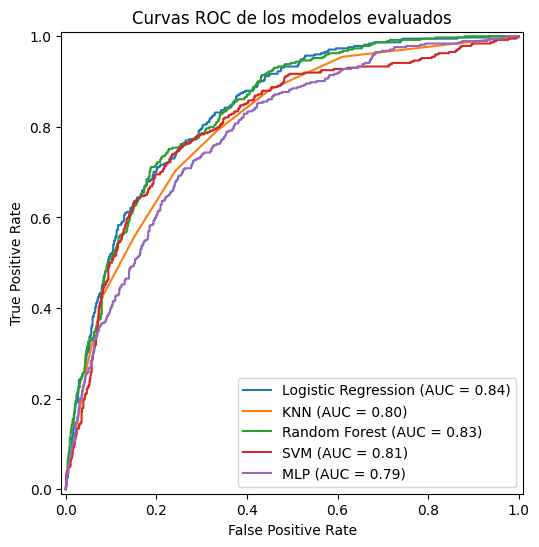

In [29]:
plt.figure(figsize=(8,6))

for name, model in best_models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=plt.gca()
    )

plt.title("Curvas ROC de los modelos evaluados")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

### Figura 1. Curvas ROC de los modelos evaluados

La Figura 1 presenta las curvas ROC obtenidas para cada uno de los modelos evaluados, permitiendo comparar visualmente su capacidad de discriminación entre clientes que abandonan el servicio y clientes que permanecen en él.

Se observa que todos los modelos presentan un desempeño superior al azar, ya que sus curvas se ubican por encima de la diagonal de referencia. Los modelos Logistic Regression y Random Forest obtuvieron las curvas más favorables y los mayores valores de AUC, evidenciando una mejor capacidad de separación entre clases.

Por su parte, KNN, SVM y MLP también mostraron resultados competitivos, aunque con un desempeño ligeramente inferior en términos de discriminación global.

Los resultados obtenidos respaldan la selección de Logistic Regression y SVM para las etapas posteriores del proyecto, debido a su adecuado balance entre sensibilidad, estabilidad y capacidad discriminativa.

### Matriz de confusión del mejor modelo

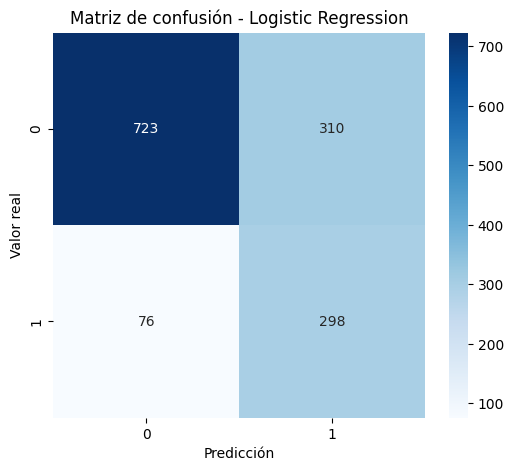

In [30]:
best_model_name = results_df.sort_values(
    by='F1-score',
    ascending=False
).iloc[0]['Model']

best_model = best_models[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(f"Matriz de confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

### Figura 2. Matriz de confusión del mejor modelo

La Figura 2 presenta la matriz de confusión correspondiente al modelo Logistic Regression, el cual obtuvo el desempeño más equilibrado durante la fase experimental.

Se observa que el modelo logró clasificar correctamente una gran cantidad de clientes pertenecientes a ambas clases. Especialmente el número de falsos negativos se mantuvo relativamente bajo, lo que resulta importante en este contexto, porque permite identificar un mayor número de clientes con riesgo de abandono.

Aunque, todavía se presantan falsos positivos considerables, indicando que algunos clientes fueron clasificados como Churn aunque realmente permanecían en el servicio. Lo cual es común en problemas desbalanceados donde se prioriza maximizar el Recall para reducir la pérdida de clientes potencialmente importantes.

### Selección de los dos mejores modelos

A partir de los resultados obtenidos durante la etapa de entrenamiento y evaluación, se seleccionaron los modelos Logistic Regression y SVM para las etapas posteriores de reducción de dimensión. La selección se realizó considerando principalmente el desempeño obtenido en términos de F1-score, Recall y ROC-AUC.

El modelo Logistic Regression presentó el mejor comportamiento general, alcanzando un F1-score de 0.6069 y un ROC-AUC de 0.8351, lo que evidencia una buena capacidad para identificar clientes con riesgo de abandono.

Por su parte, el modelo SVM obtuvo resultados similares y mostró un desempeño estable durante la validación cruzada, alcanzando un Recall de 0.7727 y un F1-score de 0.6027.

Debido a que ambos modelos mostraron el desempeño más equilibrado entre capacidad discriminativa y estabilidad durante la validación, fueron seleccionados para evaluar el efecto de las técnicas de reducción de dimensión PCA y UMAP sobre el rendimiento predictivo del sistema.

## 5. Reducción de dimensión

### 5.1. Análisis individual de variables.

Con el objetivo de identificar variables redundantes o con baja capacidad discriminativa, se realizó un análisis individual utilizando medidas de correlación e importancia de variables.

### Correlación entre variables numéricas

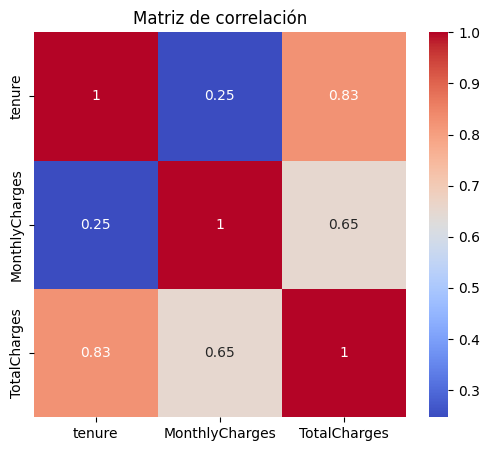

In [31]:
corr = df[
    ['tenure', 'MonthlyCharges', 'TotalCharges']
].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Matriz de correlación")

plt.show()

### Figura 3. Matriz de correlación entre variables numéricas
La Figura 3 muestra la correlación existente entre las variables numéricas del dataset. Se observa una correlación alta entre tenure y TotalCharges, lo cual resulta coherente debido a que los clientes con mayor tiempo de permanencia suelen acumular mayores costos totales de servicio.

Asimismo, MonthlyCharges presenta una correlación moderada con TotalCharges, indicando que el valor mensual influye directamente en el gasto acumulado del cliente.

Por otro lado, la correlación entre tenure y MonthlyCharges es relativamente baja, lo que sugiere que el tiempo de permanencia de un cliente no depende directamente del costo mensual contratado.

En general, los resultados evidencian cierta redundancia entre algunas variables numéricas, especialmente entre tenure y TotalCharges, las cuales podrían aportar información similar durante el proceso de clasificación.

### Importancia de variables

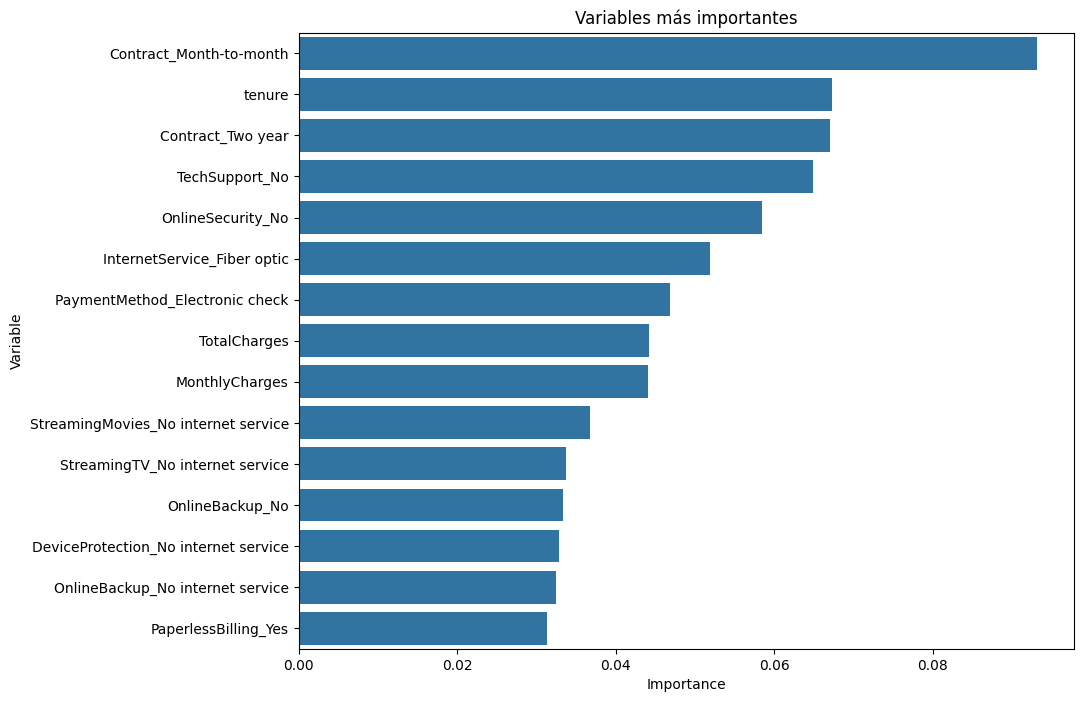

In [32]:
from sklearn.feature_selection import mutual_info_classif

X_encoded = pd.get_dummies(X)

mi_scores = mutual_info_classif(
    X_encoded,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    'Variable': X_encoded.columns,
    'Importance': mi_scores
})

mi_df = mi_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=mi_df.head(15),
    x='Importance',
    y='Variable'
)

plt.title("Variables más importantes")

plt.show()

### Figura 4. Importancia de variables usando Mutual Information
La Figura 4 presenta las variables con mayor capacidad discriminativa respecto a la variable objetivo Churn. Los resultados muestran que características relacionadas con el tipo de contrato, tiempo de permanencia y servicios adicionales poseen una alta influencia sobre la probabilidad de abandono de clientes.

La variable con mayor importancia corresponde a Contract_Month-to-month, lo cual sugiere que los clientes con contratos mensuales presentan una mayor tendencia a cancelar el servicio.

De igual forma, variables como tenure, Contract_Two year, TechSupport y OnlineSecurity muestran una contribución importante en la predicción del abandono, indicando que tanto la estabilidad contractual como los servicios complementarios influyen significativamente en la retención de clientes.

### Extracción de características lineal (PCA)

In [33]:
from sklearn.decomposition import PCA

### Aplicación del PCA

El proceso de codificación mediante One-Hot Encoding incrementó considerablemente el número de variables originales del dataset, obteniendo finalmente un total de 46 características utilizadas para el entrenamiento de los modelos.

Este incremento en dimensionalidad hizo necesario evaluar técnicas de reducción de dimensión que permitieran disminuir la complejidad computacional del problema sin perder información relevante para la clasificación.

Número original de variables: 45


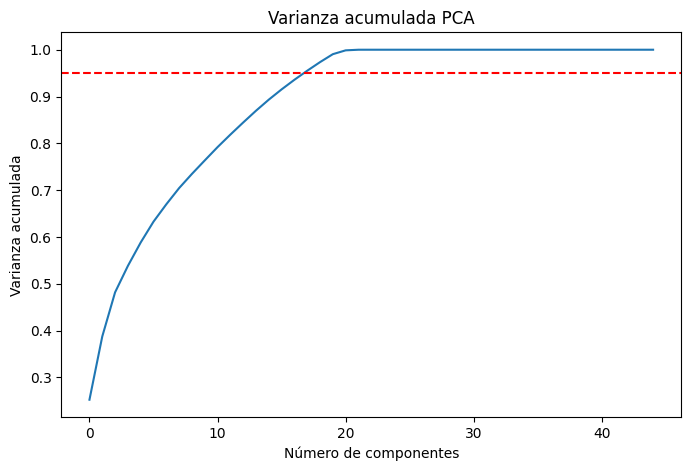

In [34]:
X_encoded = pd.get_dummies(X)

print("Número original de variables:", X_encoded.shape[1])

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(explained_variance)

plt.axhline(
    y=0.95,
    color='r',
    linestyle='--'
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")

plt.title("Varianza acumulada PCA")

plt.show()

### Figura 5. Varianza acumulada explicativa por PCA
La Figura 5 presenta la varianza acumulada explicada por los componentes principales obtenidos mediante PCA.

Se observa que la varianza acumulada aumenta progresivamente a medida que se incorporan más componentes principales. La línea de referencia correspondiente al 95% de varianza acumulada es alcanzada aproximadamente con 18 componentes, indicando que es posible representar la mayor parte de la información original utilizando un número considerablemente menor de variables.

Estos resultados muestran que PCA permite reducir la dimensionalidad del dataset conservando gran parte de la información relevante para la predicción de Churn.

### Selección de componentes
Como criterio de selección, se decidió conservar el número mínimo de componentes principales capaces de explicar al menos el 95% de la varianza acumulada del dataset original.

In [35]:
n_components = np.argmax(
    explained_variance >= 0.95
) + 1

pca = PCA(n_components=n_components)

X_pca = pca.fit_transform(X_scaled)

print("Número de componentes:", n_components)

Número de componentes: 18


El procedimiento implementado permitió identificar automáticamente el primer componente donde la varianza acumulada alcanzaba dicho umbral, obteniendo finalmente un total de 18 componentes principales.

A continuación el dataset fue transformado utilizando únicamente estas componentes, permitiendo reducir la dimensionalidad del problema y disminuir la complejidad computacional sin generar pérdidas significativas de información.

### Resultados de clasificación utilizando PCA

In [36]:
# División train/test para PCA
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Modelos seleccionados
pca_models = {
    "Logistic Regression": LogisticRegression(
        C=1,
        max_iter=1000,
        class_weight='balanced'
    ),

    "SVM": SVC(
        C=1,
        kernel='rbf',
        probability=True,
        class_weight='balanced'
    )
}

# Resultados PCA
pca_results = []

for name, model in pca_models.items():

    model.fit(X_train_pca, y_train_pca)

    y_pred = model.predict(X_test_pca)
    y_prob = model.predict_proba(X_test_pca)[:,1]

    pca_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_pca, y_pred),
        'Precision': precision_score(y_test_pca, y_pred),
        'Recall': recall_score(y_test_pca, y_pred),
        'F1-score': f1_score(y_test_pca, y_pred),
        'ROC-AUC': roc_auc_score(y_test_pca, y_prob)
    })

pca_results_df = pd.DataFrame(pca_results)

pca_results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.727790,0.492334,0.772727,0.601457,0.822249
1,SVM,0.724947,0.488964,0.770053,0.598131,0.797401


Posteriormente, los modelos Logistic Regression y SVM fueron reentrenados utilizando la representación reducida generada mediante PCA.

Los resultados obtenidos muestran que ambos modelos conservaron un desempeño competitivo respecto a los resultados alcanzados utilizando el conjunto original de variables. Esto evidencia que PCA logró preservar gran parte de la información discriminativa necesaria para la predicción del abandono de clientes.

Adicionalmente, la reducción dimensional permitió disminuir el número de variables de 46 características originales a únicamente 18 componentes principales, lo que representa una reducción aproximada del 60.9%.

### 5.3. Extracción de características no lineal (UMAP)

In [37]:
!pip install umap-learn

In [38]:
import umap.umap_ as umap

In [41]:
umap_model = umap.UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.1,
)

X_umap = umap_model.fit_transform(X_scaled)

print(X_umap.shape)

(7032, 5)


Como alternativa no lineal de reducción de dimensión, se utilizó UMAP, una técnica que permite preservar relaciones complejas entre variables utilizando representaciones de menor dimensionalidad.

En este caso, se configuró el modelo para generar únicamente 5 componentes reducidos.

Como resultado, el dataset original fue transformado a una nueva representación de tamaño (7032, 5), reduciendo significativamente la complejidad del problema respecto al conjunto original de variables.

### Resultados de clasificación utilizando UMAP

In [42]:
# División train/test para UMAP
X_train_umap, X_test_umap, y_train_umap, y_test_umap = train_test_split(
    X_umap,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Resultados UMAP
umap_results = []

for name, model in pca_models.items():

    model.fit(X_train_umap, y_train_umap)

    y_pred = model.predict(X_test_umap)
    y_prob = model.predict_proba(X_test_umap)[:,1]

    umap_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_umap, y_pred),
        'Precision': precision_score(y_test_umap, y_pred),
        'Recall': recall_score(y_test_umap, y_pred),
        'F1-score': f1_score(y_test_umap, y_pred),
        'ROC-AUC': roc_auc_score(y_test_umap, y_prob)
    })

umap_results_df = pd.DataFrame(umap_results)

umap_results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.671642,0.436232,0.804813,0.565789,0.773007
1,SVM,0.674485,0.439130,0.810160,0.569549,0.794299


Posteriormente, se evaluaron nuevamente los modelos Logistic Regression y SVM utilizando la representación reducida obtenida mediante UMAP.

Los resultados muestran que UMAP permitió reducir considerablemente la dimensionalidad del problema manteniendo un desempeño relativamente competitivo en ambos modelos.

En comparación con PCA, UMAP logró una representación mucho más compacta del dataset, alcanzando una reducción aproximada del 89.1% respecto al número original de variables.

Esto demuestra que las técnicas no lineales de reducción de dimensión pueden conservar relaciones complejas entre variables incluso utilizando un número muy reducido de componentes.

### Comparación de reducción dimensional

In [43]:
comparison_df = pd.DataFrame({
    'Técnica': ['Original', 'PCA', 'UMAP'],
    'Número de variables': [46, 18, 5],
    'Reducción (%)': [
        0,
        round((1 - 18/46)*100, 2),
        round((1 - 5/46)*100, 2)
    ]
})

comparison_df

,Técnica,Número de variables,Reducción (%)
0,Original,46,0.00
1,PCA,18,60.87
2,UMAP,5,89.13


La tabla comparativa de reducción dimensional resume el número de variables utilizadas en cada escenario evaluado.

PCA permitió conservar aproximadamente el 95% de la varianza del dataset utilizando únicamente 18 componentes principales, mientras que UMAP logró reducir la representación a solo 5 componentes.

En términos generales, ambas técnicas permitieron disminuir significativamente la complejidad computacional del problema manteniendo resultados predictivos competitivos.

## Discusión y conclusiones
En este proyecto se evaluaron diferentes modelos de clasificación supervisada para predecir el abandono de clientes en una empresa de telecomunicaciones utilizando el dataset Telco Customer Churn.

Los resultados obtenidos evidenciaron diferencias importantes en el desempeño de los modelos evaluados y permitieron identificar las variables con mayor capacidad discriminativa para el problema.

Durante la etapa de entrenamiento y evaluación, los modelos Logistic Regression y SVM presentaron el comportamiento más equilibrado considerando métricas como Recall, F1-score y ROC-AUC. En particular, Logistic Regression obtuvo el mejor desempeño general, mostrando una buena capacidad para identificar clientes con riesgo de abandono.

El análisis de curvas ROC evidenció que todos los modelos lograron una capacidad discriminativa adecuada, aunque Logistic Regression y Random Forest presentaron los mejores valores de AUC.

Por otra parte, la matriz de confusión permitió observar que el mejor modelo logró identificar correctamente una gran cantidad de clientes con Churn, aunque todavía se presentan falsos positivos y falsos negativos debido al desbalance inherente del problema.

El análisis individual de variables mostró que características relacionadas con el tipo de contrato, tiempo de permanencia y servicios adicionales poseen una influencia significativa sobre el comportamiento de abandono de clientes.

Respecto a la reducción de dimensión, PCA permitió conservar aproximadamente el 95% de la información original utilizando únicamente 18 componentes principales, mientras que UMAP logró una representación aún más compacta mediante solo 5 componentes.

En términos generales, ambas técnicas permitieron reducir la complejidad computacional manteniendo resultados competitivos de clasificación.

Finalmente, los resultados obtenidos demuestran que tanto modelos lineales como no lineales pueden ofrecer un desempeño adecuado para problemas de predicción de Churn, y que las técnicas de reducción de dimensión representan una alternativa útil para simplificar el problema sin afectar significativamente la capacidad predictiva de los modelos.